# Random Forest Model (Enhanced, With Automatic Tuning)



In [1]:
import os
import sys
import importlib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

sys.path.append(os.path.abspath('..'))


import src.model_utils as model_utils
importlib.reload(model_utils)

evaluate_classifier = model_utils.evaluate_classifier
get_confusion_matrix_df = model_utils.get_confusion_matrix_df
load_encoded_splits = model_utils.load_encoded_splits
plot_metric_scorecards = model_utils.plot_metric_scorecards
plot_roc_curve = model_utils.plot_roc_curve
run_random_search = model_utils.run_random_search

In [2]:
DATA_DIR = '../data/'
X_train, y_train, X_val, y_val, X_test, y_test = load_encoded_splits(DATA_DIR, version="enhanced")

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}, y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')

Splits loaded successfully.
X_train: (60876, 32), y_train: (60876,)
X_val: (13045, 32), y_val: (13045,)
X_test: (13046, 32), y_test: (13046,)
X_train: (60876, 86), y_train: (60876,)
X_val:   (13045, 86), y_val:   (13045,)
X_test:  (13046, 86), y_test:  (13046,)


In [3]:
SEED = 42

base_rf = RandomForestClassifier(random_state=SEED, n_jobs=-1)

param_distributions = {
    'n_estimators': [80, 120, 160, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

search = run_random_search(
    estimator=base_rf,
    param_distributions=param_distributions,
    X_train=X_train,
    y_train=y_train,
    n_iter=8,
    cv=3,
    scoring='f1',
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)

best_rf = search.best_estimator_
print('Best params:', search.best_params_)
print(f'Best CV f1: {search.best_score_:.4f}')

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'n_estimators': 120, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV f1: 0.6800


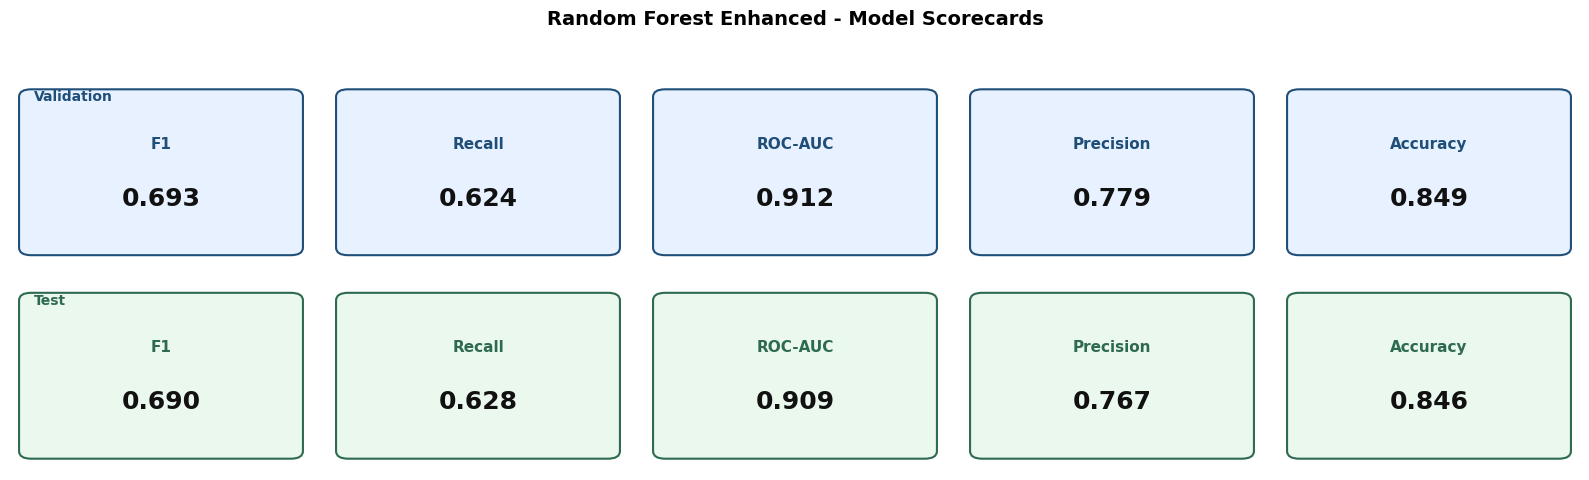

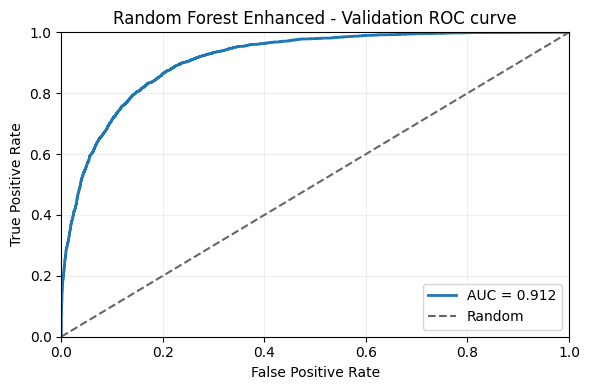

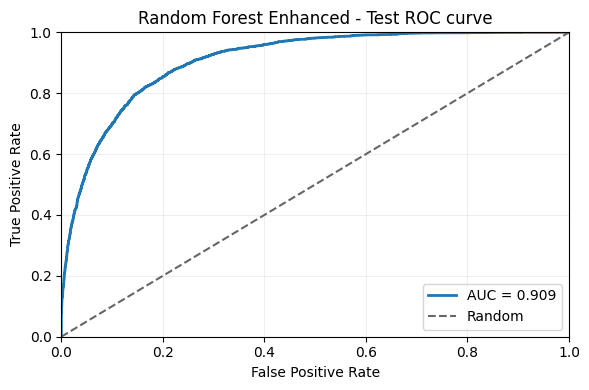

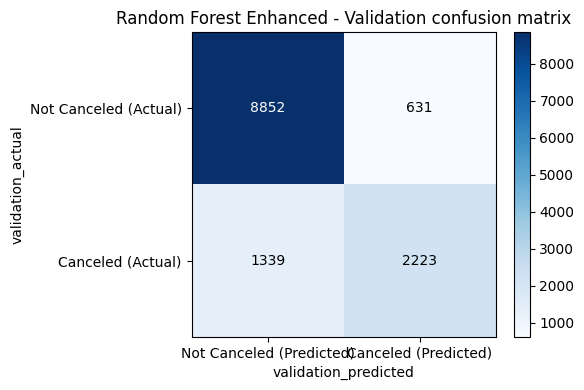

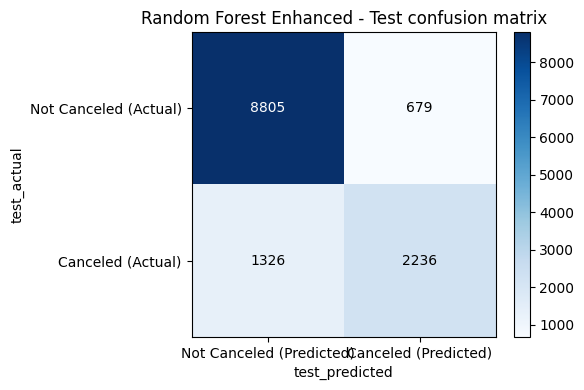

,split,accuracy,precision,recall,f1,roc_auc
0,validation,0.8490,0.7789,0.6241,0.6930,0.9118
1,test,0.8463,0.7671,0.6277,0.6904,0.9085


In [4]:
val_results = evaluate_classifier(best_rf, X_val, y_val, 'validation')
test_results = evaluate_classifier(best_rf, X_test, y_test, 'test')
plot_metric_scorecards(val_results, test_results, notebook_name='06_random_forest_enhanced.ipynb')
plot_roc_curve(best_rf, X_val, y_val, 'validation', notebook_name='06_random_forest_enhanced.ipynb')
plot_roc_curve(best_rf, X_test, y_test, 'test', notebook_name='06_random_forest_enhanced.ipynb')
val_cm = get_confusion_matrix_df(best_rf, X_val, y_val, 'validation', notebook_name='06_random_forest_enhanced.ipynb', plot=True)
test_cm = get_confusion_matrix_df(best_rf, X_test, y_test, 'test', notebook_name='06_random_forest_enhanced.ipynb', plot=True)

results_df = pd.DataFrame([val_results, test_results])
display(results_df.round(4))

In [5]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_,
}).sort_values('importance', ascending=False)

display(importance_df.head(15))

,feature,importance
0,lead_time,0.106622
15,total_of_special_requests,0.072181
31,country_PRT,0.067021
49,total_cost,0.051949
13,adr,0.047951
48,cost_per_person,0.044820
14,required_car_parking_spaces,0.036918
2,arrival_date_day_of_month,0.035288
43,week_sin,0.032026
44,week_cos,0.030265
